# Chapter 5: Pretraining on Unlabeled Data

In [1]:
# from importlib.metadata import version

# pkgs = ["matplotlib", 
#         "numpy", 
#         "tiktoken", 
#         "torch",
#         "tensorflow" # For OpenAI's pretrained weights
#        ]
# for p in pkgs:
#     print(f"{p} version: {version(p)}")

- In this chapter, we implement the training loop and code for basic model evaluation to pretrain an LLM
- At the end of this chapter, we also load openly available pretrained weights from OpenAI into our model


![figure](https://learning.oreilly.com/api/v2/epubs/urn:orm:book:9781633437166/files/OEBPS/Images/5-1.png)

##### Figure 5.1  The three main stages of coding an LLM. This chapter focuses on stage 2: pretraining the LLM (step 4), which includes implementing the training code (step 5), evaluating the performance (step 6), and saving and loading model weights (step 7).

- The topics covered in this chapter are shown below


![figure](https://learning.oreilly.com/api/v2/epubs/urn:orm:book:9781633437166/files/OEBPS/Images/5-2.png)

## 5.1 Evaluating generative text models

- We start this section with a brief recap of initializing a GPT model using the code from the previous chapter
- Then, we discuss basic evaluation metrics for LLMs
- Lastly, in this section, we apply these evaluation metrics to a training and validation dataset

### 5.1.1 Using GPT to generate text

- We initialize a GPT model using the code from the previous chapter

In [2]:
import torch

#
# This file collects all the relevant code that we covered thus far
# throughout Chapters 2-4.
# This file can be run as a standalone script.

import tiktoken
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

#####################################
# Chapter 2
#####################################


class GPTDatasetV1(Dataset):
    def __init__(self, txt, tokenizer, max_length, stride):
        self.input_ids = []
        self.target_ids = []

        # Tokenize the entire text
        token_ids = tokenizer.encode(txt, allowed_special={"<|endoftext|>"})

        # Use a sliding window to chunk the book into overlapping sequences of max_length
        for i in range(0, len(token_ids) - max_length, stride):
            input_chunk = token_ids[i:i + max_length]
            target_chunk = token_ids[i + 1: i + max_length + 1]
            self.input_ids.append(torch.tensor(input_chunk))
            self.target_ids.append(torch.tensor(target_chunk))

    def __len__(self):
        return len(self.input_ids)

    def __getitem__(self, idx):
        return self.input_ids[idx], self.target_ids[idx]


def create_dataloader_v1(txt, batch_size=4, max_length=256,
                         stride=128, shuffle=True, drop_last=True, num_workers=0):
    # Initialize the tokenizer
    tokenizer = tiktoken.get_encoding("gpt2")

    # Create dataset
    dataset = GPTDatasetV1(txt, tokenizer, max_length, stride)

    # Create dataloader
    dataloader = DataLoader(
        dataset, batch_size=batch_size, shuffle=shuffle, drop_last=drop_last, num_workers=num_workers)

    return dataloader


#####################################
# Chapter 3
#####################################
class MultiHeadAttention(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
        super().__init__()
        assert d_out % num_heads == 0, "d_out must be divisible by n_heads"

        self.d_out = d_out
        self.num_heads = num_heads
        self.head_dim = d_out // num_heads  # Reduce the projection dim to match desired output dim

        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.out_proj = nn.Linear(d_out, d_out)  # Linear layer to combine head outputs
        self.dropout = nn.Dropout(dropout)
        self.register_buffer('mask', torch.triu(torch.ones(context_length, context_length), diagonal=1))

    def forward(self, x):
        b, num_tokens, d_in = x.shape

        keys = self.W_key(x)  # Shape: (b, num_tokens, d_out)
        queries = self.W_query(x)
        values = self.W_value(x)

        # We implicitly split the matrix by adding a `num_heads` dimension
        # Unroll last dim: (b, num_tokens, d_out) -> (b, num_tokens, num_heads, head_dim)
        keys = keys.view(b, num_tokens, self.num_heads, self.head_dim)
        values = values.view(b, num_tokens, self.num_heads, self.head_dim)
        queries = queries.view(b, num_tokens, self.num_heads, self.head_dim)

        # Transpose: (b, num_tokens, num_heads, head_dim) -> (b, num_heads, num_tokens, head_dim)
        keys = keys.transpose(1, 2)
        queries = queries.transpose(1, 2)
        values = values.transpose(1, 2)

        # Compute scaled dot-product attention (aka self-attention) with a causal mask
        attn_scores = queries @ keys.transpose(2, 3)  # Dot product for each head

        # Original mask truncated to the number of tokens and converted to boolean
        mask_bool = self.mask.bool()[:num_tokens, :num_tokens]

        # Use the mask to fill attention scores
        attn_scores.masked_fill_(mask_bool, -torch.inf)

        attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)
        attn_weights = self.dropout(attn_weights)

        # Shape: (b, num_tokens, num_heads, head_dim)
        context_vec = (attn_weights @ values).transpose(1, 2)

        # Combine heads, where self.d_out = self.num_heads * self.head_dim
        context_vec = context_vec.reshape(b, num_tokens, self.d_out)
        context_vec = self.out_proj(context_vec)  # optional projection

        return context_vec


#####################################
# Chapter 4
#####################################
class LayerNorm(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        self.eps = 1e-5
        self.scale = nn.Parameter(torch.ones(emb_dim))
        self.shift = nn.Parameter(torch.zeros(emb_dim))

    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        norm_x = (x - mean) / torch.sqrt(var + self.eps)
        return self.scale * norm_x + self.shift


class GELU(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        return 0.5 * x * (1 + torch.tanh(
            torch.sqrt(torch.tensor(2.0 / torch.pi)) *
            (x + 0.044715 * torch.pow(x, 3))
        ))


class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(cfg["emb_dim"], 4 * cfg["emb_dim"]),
            GELU(),
            nn.Linear(4 * cfg["emb_dim"], cfg["emb_dim"]),
        )

    def forward(self, x):
        return self.layers(x)


class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.att = MultiHeadAttention(
            d_in=cfg["emb_dim"],
            d_out=cfg["emb_dim"],
            context_length=cfg["context_length"],
            num_heads=cfg["n_heads"],
            dropout=cfg["drop_rate"],
            qkv_bias=cfg["qkv_bias"])
        self.ff = FeedForward(cfg)
        self.norm1 = LayerNorm(cfg["emb_dim"])
        self.norm2 = LayerNorm(cfg["emb_dim"])
        self.drop_shortcut = nn.Dropout(cfg["drop_rate"])

    def forward(self, x):
        # Shortcut connection for attention block
        shortcut = x
        x = self.norm1(x)
        x = self.att(x)   # Shape [batch_size, num_tokens, emb_size]
        x = self.drop_shortcut(x)
        x = x + shortcut  # Add the original input back

        # Shortcut connection for feed-forward block
        shortcut = x
        x = self.norm2(x)
        x = self.ff(x)
        x = self.drop_shortcut(x)
        x = x + shortcut  # Add the original input back

        return x


class GPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])

        self.trf_blocks = nn.Sequential(
            *[TransformerBlock(cfg) for _ in range(cfg["n_layers"])])

        self.final_norm = LayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(cfg["emb_dim"], cfg["vocab_size"], bias=False)

    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)
        pos_embeds = self.pos_emb(torch.arange(seq_len, device=in_idx.device))
        x = tok_embeds + pos_embeds  # Shape [batch_size, num_tokens, emb_size]
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits


def generate_text_simple(model, idx, max_new_tokens, context_size):
    # idx is (B, T) array of indices in the current context
    for _ in range(max_new_tokens):

        # Crop current context if it exceeds the supported context size
        # E.g., if LLM supports only 5 tokens, and the context size is 10
        # then only the last 5 tokens are used as context
        idx_cond = idx[:, -context_size:]

        # Get the predictions
        with torch.no_grad():
            logits = model(idx_cond)

        # Focus only on the last time step
        # (batch, n_token, vocab_size) becomes (batch, vocab_size)
        logits = logits[:, -1, :]

        # Get the idx of the vocab entry with the highest logits value
        idx_next = torch.argmax(logits, dim=-1, keepdim=True)  # (batch, 1)

        # Append sampled index to the running sequence
        idx = torch.cat((idx, idx_next), dim=1)  # (batch, n_tokens+1)

    return idx


if __name__ == "__main__":

    GPT_CONFIG_124M = {
        "vocab_size": 50257,     # Vocabulary size
        "context_length": 1024,  # Context length
        "emb_dim": 768,          # Embedding dimension
        "n_heads": 12,           # Number of attention heads
        "n_layers": 12,          # Number of layers
        "drop_rate": 0.1,        # Dropout rate
        "qkv_bias": False        # Query-Key-Value bias
    }

    torch.manual_seed(123)
    model = GPTModel(GPT_CONFIG_124M)
    model.eval()  # disable dropout

    start_context = "Hello, I am"

    tokenizer = tiktoken.get_encoding("gpt2")
    encoded = tokenizer.encode(start_context)
    encoded_tensor = torch.tensor(encoded).unsqueeze(0)

    print(f"\n{50*'='}\n{22*' '}IN\n{50*'='}")
    print("\nInput text:", start_context)
    print("Encoded input text:", encoded)
    print("encoded_tensor.shape:", encoded_tensor.shape)

    out = generate_text_simple(
        model=model,
        idx=encoded_tensor,
        max_new_tokens=10,
        context_size=GPT_CONFIG_124M["context_length"]
    )
    decoded_text = tokenizer.decode(out.squeeze(0).tolist())

    print(f"\n\n{50*'='}\n{22*' '}OUT\n{50*'='}")
    print("\nOutput:", out)
    print("Output length:", len(out[0]))
    print("Output text:", decoded_text)

GPT_CONFIG_124M = {
    "vocab_size": 50257,   # Vocabulary size
    "context_length": 256, # Shortened context length (orig: 1024)
    "emb_dim": 768,        # Embedding dimension
    "n_heads": 12,         # Number of attention heads
    "n_layers": 12,        # Number of layers
    "drop_rate": 0.1,      # Dropout rate
    "qkv_bias": False      # Query-key-value bias
}

torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.eval();  # Disable dropout during inference


                      IN

Input text: Hello, I am
Encoded input text: [15496, 11, 314, 716]
encoded_tensor.shape: torch.Size([1, 4])


                      OUT

Output: tensor([[15496,    11,   314,   716, 27018, 24086, 47843, 30961, 42348,  7267,
         49706, 43231, 47062, 34657]])
Output length: 14
Output text: Hello, I am Featureiman Byeswickattribute argue logger Normandy Compton analogous


- We use dropout of 0.1 above, but it's relatively common to train LLMs without dropout nowadays
- Modern LLMs also don't use bias vectors in the `nn.Linear` layers for the query, key, and value matrices (unlike earlier GPT models), which is achieved by setting `"qkv_bias": False`
- We reduce the context length (`context_length`) of only 256 tokens to reduce the computational resource requirements for training the model, whereas the original 124 million parameter GPT-2 model used 1024 tokens
  - This is so that more readers will be able to follow and execute the code examples on their laptop computer
  - However, please feel free to increase the `context_length` to 1024 tokens (this would not require any code changes)
  - We will also load a model with a 1024 `context_length` later from pretrained weights

- Next, we use the `generate_text_simple` function 
- In addition, we define two convenience functions, `text_to_token_ids` and `token_ids_to_text`, for converting between token and text representations that we use throughout this chapter

![figure](https://learning.oreilly.com/api/v2/epubs/urn:orm:book:9781633437166/files/OEBPS/Images/5-3.png)

##### Figure 5.3  Generating text involves encoding text into token IDs that the LLM processes into logit vectors. The logit vectors are then converted back into token IDs, detokenized into a text representation.

In [3]:
import tiktoken

def text_to_token_ids(text, tokenizer):
    encoded = tokenizer.encode(text, allowed_special={'<|endoftext|>'})
    encoded_tensor = torch.tensor(encoded).unsqueeze(0) # add batch dimension
    return encoded_tensor

def token_ids_to_text(token_ids, tokenizer):
    flat = token_ids.squeeze(0) # remove batch dimension
    return tokenizer.decode(flat.tolist())

start_context = "Every effort moves you"
tokenizer = tiktoken.get_encoding("gpt2")

token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids(start_context, tokenizer),
    max_new_tokens=10,
    context_size=GPT_CONFIG_124M["context_length"]
)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you rentingetic wasnم refres RexMeCHicular stren


Output text:
 - Every effort moves you rentingetic wasnم refres RexMeCHicular stren

- As we can see above, the model does not produce good text because it has not been trained yet
- How do we measure or capture what "good text" is, in a numeric form, to track it during training?
- The next subsection introduces metrics to calculate a loss metric for the generated outputs that we can use to measure the training progress
- The next chapters on finetuning LLMs will also introduce additional ways to measure model quality

<br>

### 5.1.2 Calculating the text generation loss: cross-entropy and perplexity

- Suppose we have an `inputs` tensor containing the token IDs for 2 training examples (rows)
- Corresponding to the `inputs`, the `targets` contain the desired token IDs that we want the model to generate
- Notice that the `targets` are the `inputs` shifted by 1 position, as explained in chapter 2 when we implemented the data loader

In [4]:
inputs = torch.tensor([[16833, 3626, 6100],   # ["every effort moves",
                       [40,    1107, 588]])   #  "I really like"]

targets = torch.tensor([[3626, 6100, 345  ],  # [" effort moves you",
                        [1107,  588, 11311]]) #  " really like chocolate"]

- Feeding the `inputs` to the model, we obtain the logits vector for the 2 input examples that consist of 3 tokens each
- Each of the tokens is a 50,257-dimensional vector corresponding to the size of the vocabulary
- Applying the softmax function, we can turn the logits tensor into a tensor of the same dimension containing probability scores 

In [5]:
with torch.no_grad():
    logits = model(inputs)

probas = torch.softmax(logits, dim=-1) # Probability of each token in vocabulary
print(probas.shape) # Shape: (batch_size, num_tokens, vocab_size)

torch.Size([2, 3, 50257])


- The figure below, using a very small vocabulary for illustration purposes, outlines how we convert the probability scores back into text, which we discussed at the end of the previous chapter


![figure](https://learning.oreilly.com/api/v2/epubs/urn:orm:book:9781633437166/files/OEBPS/Images/5-4.png)

##### Figure 5.4  For each of the three input tokens, shown on the left, we compute a vector containing probability scores corresponding to each token in the vocabulary. The index position of the highest probability score in each vector represents the most likely next token ID. These token IDs associated with the highest probability scores are selected and mapped back into a text that represents the text generated by the model.

- As discussed in the previous chapter, we can apply the `argmax` function to convert the probability scores into predicted token IDs
- The softmax function above produced a 50,257-dimensional vector for each token; the `argmax` function returns the position of the highest probability score in this vector, which is the predicted token ID for the given token

- Since we have 2 input batches with 3 tokens each, we obtain 2 by 3 predicted token IDs:

In [6]:
token_ids = torch.argmax(probas, dim=-1, keepdim=True)
print("Token IDs:\n", token_ids)

Token IDs:
 tensor([[[16657],
         [  339],
         [42826]],

        [[49906],
         [29669],
         [41751]]])


- If we decode these tokens, we find that these are quite different from the tokens we want the model to predict, namely the target tokens:

In [7]:
print(f"Targets batch 1: {token_ids_to_text(targets[0], tokenizer)}")
print(f"Outputs batch 1: {token_ids_to_text(token_ids[0].flatten(), tokenizer)}")

Targets batch 1:  effort moves you
Outputs batch 1:  Armed heNetflix


- That's because the model wasn't trained yet
- To train the model, we need to know how far it is away from the correct predictions (targets)

![figure](https://learning.oreilly.com/api/v2/epubs/urn:orm:book:9781633437166/files/OEBPS/Images/5-6.png)

##### Figure 5.6  Before training, the model produces random next-token probability vectors. The goal of model training is to ensure that the probability values corresponding to the highlighted target token IDs are maximized.

### **4. Loss Calculation and Model Training**
-   **Objective:**
    -   The training process aims to maximize the probability of the correct (target) token.
-   **Loss Function Role:**    
    -   Measures how "far" the generated tokens are from the target tokens.
    -   Guides the model’s weight adjustments during training so that the probability for the correct token increases over time.
-   **Outcome:**    
    -   A lower loss indicates that the model's predictions are closer to the target sequence.
    -   With training, the model learns to generate text that more accurately reflects the expected output.

- The token probabilities corresponding to the target indices are as follows:


**1. The Need for a Loss Function**

*   **Backpropagation's Guide:** Backpropagation, the algorithm that updates the model's weights, needs a way to measure how "wrong" the model's predictions are. This is the role of the *loss function*.
*   **Prediction vs. Reality:** The loss function compares the model's predicted output (probabilities for the next token) to the actual desired output (the correct next token).
*   **Goal:**  The loss function quantifies the difference between the prediction and the truth.  A lower loss means the model is doing better.

**2.  Step-by-Step Loss Calculation (Manual Approach - for Understanding)**

The text walks through calculating the loss manually *before* introducing PyTorch's built-in function. This is excellent for building intuition.  Let's summarize the steps (referencing Figure 5.7):

*   **Steps 1-3 (Already Done):** These steps involve getting the probability scores for the *target* tokens.  This means:
    1.  Run the input through the model to get `logits`.
    2.  Apply `softmax` to the `logits` to get probabilities.
    3.  Select the probabilities that correspond to the *correct* next tokens (the targets).  We did this in a previous section, ending up with `target_probas_1` and `target_probas_2`.

In [ ]:
text_idx = 0
target_probas_1 = probas[text_idx, [0, 1, 2], targets[text_idx]]
print("Text 1:", target_probas_1)

text_idx = 1
target_probas_2 = probas[text_idx, [0, 1, 2], targets[text_idx]]

print("Text 2:", target_probas_2)

Text 1: tensor([7.4541e-05, 3.1061e-05, 1.1563e-05])
Text 2: tensor([1.0337e-05, 5.6776e-05, 4.7559e-06])


> Text 1: tensor([7.4541e-05, 3.1061e-05, 1.1563e-05])

> Text 2: tensor([1.0337e-05, 5.6776e-05, 4.7559e-06])


The resulting tensor dimension of the probability score (`probas`) tensor is

> torch.Size([2, 3, 50257])

 - The first number, 2, corresponds to the two examples (rows) in the
   inputs, also known as batch size.  
  - The second number, 3, corresponds
   to the number of tokens in each input (row). 
   - The last number corresponds to the embedding dimensionality, which is determined by   the vocabulary size.


- We want to maximize all these values, bringing them close to a probability of 1
- In mathematical optimization, it is easier to maximize the logarithm of the probability score than the probability score itself; 

In [9]:
# Compute logarithm of all token probabilities
log_probas = torch.log(torch.cat((target_probas_1, target_probas_2)))
print(log_probas)

tensor([ -9.5042, -10.3796, -11.3677, -11.4798,  -9.7764, -12.2561])



*   **`torch.cat(...)`:** Combines the probability scores from the two batches into a single tensor.
*   **`torch.log(...)`:**  Takes the natural logarithm of each probability.
*   **Why Logarithms?**
    *   **Numerical Stability:** Probabilities can be very small (close to 0).  `Multiplying many small probabilities together can lead to *underflow* (the number becomes so small that the computer represents it as 0`).  Logarithms transform multiplication into addition, avoiding this problem.
    *   **Mathematical Convenience:**  `The derivative of the log is simpler than the derivative of the original probability`, which makes the optimization process (backpropagation) easier.  **Key interview point!**
*   **Result:**  Negative values.  The log of a number between 0 and 1 is always negative. The closer the original probability was to 1, the closer the log probability is to 0.


- Next, we compute the average log probability:

In [10]:
# Calculate the average probability for each token
avg_log_probas = torch.mean(log_probas)
print(avg_log_probas)

tensor(-10.7940)


- The goal is to make this average log probability as large as possible by optimizing the model weights
- Due to the log, the largest possible value is 0, and we are currently far away from 0

- In deep learning, instead of maximizing the average log-probability, it's a standard convention to minimize the *negative* average log-probability value; in our case, instead of maximizing -10.7722 so that it approaches 0, in deep learning, we would minimize 10.7722 so that it approaches 0
- The value negative of -10.7722, i.e., 10.7722, is also called cross-entropy loss in deep learning

In [11]:
neg_avg_log_probas = avg_log_probas * -1
print(neg_avg_log_probas)

tensor(10.7940)


*   **Multiply by -1:**  This turns the negative average log probability into a positive value.
*   **Why?**  `By convention, optimization algorithms in deep learning are designed to *minimize* a loss function.  We want to *maximize* the log probability, which is the same as *minimizing* the *negative* log probability`. **Crucial interview point!**
*   **This is the Loss:** `This final positive value is what we call the loss.  The lower the loss, the better the model's predictions.`

- PyTorch already implements a `cross_entropy` function that carries out the previous steps

![figure](https://learning.oreilly.com/api/v2/epubs/urn:orm:book:9781633437166/files/OEBPS/Images/5-7.png)

##### Figure 5.7  Calculating the loss involves several steps. Steps 1 to 3, which we have already completed, calculate the token probabilities corresponding to the target tensors. These probabilities are then transformed via a logarithm and averaged in steps 4 to 6.

- Before we apply the `cross_entropy` function, let's check the shape of the logits and targets

In [12]:
# Logits have shape (batch_size, num_tokens, vocab_size)
print("Logits shape:", logits.shape)

# Targets have shape (batch_size, num_tokens)
print("Targets shape:", targets.shape)

Logits shape: torch.Size([2, 3, 50257])
Targets shape: torch.Size([2, 3])


In [28]:
targets

tensor([[ 3626,  6100,   345],
        [ 1107,   588, 11311]])

- For the `cross_entropy` function in PyTorch, we want to flatten these tensors by combining them over the batch dimension:

In [13]:
logits_flat = logits.flatten(0, 1)
targets_flat = targets.flatten()

print("Flattened logits:", logits_flat.shape)
print("Flattened targets:", targets_flat.shape)

Flattened logits: torch.Size([6, 50257])
Flattened targets: torch.Size([6])


In [29]:
targets_flat

tensor([ 3626,  6100,   345,  1107,   588, 11311])

- Note that the targets are the token IDs, which also represent the index positions in the logits tensors that we want to maximize
- The `cross_entropy` function in PyTorch will automatically take care of applying the softmax and log-probability computation internally over those token indices in the logits that are to be maximized 

In [14]:
loss = torch.nn.functional.cross_entropy(logits_flat, targets_flat)
print(loss)

tensor(10.7940)



*   **`torch.nn.functional.cross_entropy(...)`:**  This function does *all* the steps (1-6) we did manually in a single, optimized operation.
*   **`logits_flat`:**  The *flattened* logits tensor.  Shape: `(batch_size * seq_len, vocab_size)`.
*   **`targets_flat`:** The *flattened* target tensor (token IDs). Shape: `(batch_size * seq_len)`.
*   **Flattening:**  The `cross_entropy` function expects the inputs to be flattened.  We combine the batch and sequence dimensions.
    *   `logits.flatten(0, 1)`: Flattens dimensions 0 and 1 of the `logits` tensor.
    *   `targets.flatten()`: Flattens the entire `targets` tensor.
*   **Important:**  `The `cross_entropy` function expects *logits* (the raw outputs of the model *before* `softmax`), *not* probabilities.  It internally applies the `softmax` and the logarithm.  **This is a very common point of confusion, so remember it!**`

- A concept related to the cross-entropy loss is the perplexity of an LLM
- The perplexity is simply the exponential of the cross-entropy loss

### **Step-by-Step Breakdown of Cross Entropy Loss Calculation**  

| **Step** | **Concept** | **Explanation** | **Code Reference** |
|----------|------------|----------------|---------------------|
| **1. Logits** | Raw Model Output | Unnormalized scores for each token in the vocabulary. Higher values indicate more confidence. | `logits = model(idx_cond)` |
| **2. Probabilities** | Softmax Applied | Converts logits into probabilities (values between 0 and 1, summing to 1). | `probas = torch.softmax(logits, dim=-1)` |
| **3. Target Probabilities** | Selecting Correct Token Probabilities | Extracts probabilities of the actual target tokens from step 2. | Done internally in `cross_entropy` |
| **4. Log Probabilities** | Logarithm Applied | Takes the natural log of the target probabilities, making computations manageable. | `log_probas = torch.log(target_probas)` |
| **5. Average Log Probability** | Mean Calculation | Averages log probabilities across all tokens in the batch. | `avg_log_probas = torch.mean(log_probas)` |
| **6. Negative Average Log Probability** | Loss Computation | Converts the value to positive for minimization in training. | `neg_avg_log_probas = avg_log_probas * -1` |

### **Final Insight:**
PyTorch’s `torch.nn.functional.cross_entropy` automates all these steps, making it the preferred approach for loss calculation in deep learning.

In [15]:
perplexity = torch.exp(loss)
print(perplexity)

tensor(48725.8203)


- The perplexity is often considered more interpretable because it can be understood as the effective vocabulary size that the model is uncertain about at each step (in the example above, that'd be 48,725 words or tokens)
- In other words, `perplexity provides a measure of how well the probability distribution predicted by the model matches the actual distribution of the words in the dataset`
- Similar to the loss, a lower perplexity indicates that the model predictions are closer to the actual distribution

- Perplexity is often considered more interpretable than the raw loss value because `it signifies the effective vocabulary size about which the model is uncertain at each step`. 
In the given example, this would translate to `the model being unsure about which among 48,725 tokens in the vocabulary to generate as the next token`.



### 5.1.3 Calculating the training and validation set losses


![figure](https://learning.oreilly.com/api/v2/epubs/urn:orm:book:9781633437166/files/OEBPS/Images/5-8.png)

##### Figure 5.8  Having completed steps 1 and 2, including computing the cross entropy loss, we can now apply this loss computation to the entire text dataset that we will use for model training.

- We use a relatively small dataset for training the LLM (in fact, only one short story)
- The reasons are:
  - You can run the code examples in a few minutes on a laptop computer without a suitable GPU
  - The training finishes relatively fast (minutes instead of weeks), which is good for educational purposes
  - We use a text from the public domain, which can be included in this GitHub repository without violating any usage rights or bloating the repository size


- For example, Llama 2 7B required 184,320 GPU hours on A100 GPUs to be trained on 2 trillion tokens
  - At the time of this writing, the hourly cost of an 8xA100 cloud server at AWS is approximately \\$30
  - So, via an off-the-envelope calculation, training this LLM would cost 184,320 / 8 * \\$30 =  \\$690,000
 
- Below, we use the same dataset we used in chapter 2

In [30]:
import os
import urllib.request

file_path = "the-verdict.txt"
url = "https://raw.githubusercontent.com/rasbt/LLMs-from-scratch/main/ch02/01_main-chapter-code/the-verdict.txt"

if not os.path.exists(file_path):
    with urllib.request.urlopen(url) as response:
        text_data = response.read().decode('utf-8')
    with open(file_path, "w", encoding="utf-8") as file:
        file.write(text_data)
else:
    with open(file_path, "r", encoding="utf-8") as file:
        text_data = file.read()

- A quick check that the text loaded ok by printing the first and last 100 words

In [31]:
# First 100 characters
print(text_data[:99])

I HAD always thought Jack Gisburn rather a cheap genius--though a good fellow enough--so it was no 


In [32]:
# Last 100 characters
print(text_data[-99:])

it for me! The Strouds stand alone, and happen once--but there's no exterminating our kind of art."


In [33]:
total_characters = len(text_data)
total_tokens = len(tokenizer.encode(text_data))

print("Characters:", total_characters)
print("Tokens:", total_tokens)

Characters: 20479
Tokens: 5145


- With 5,145 tokens, the text is very short for training an LLM, but again, it's for educational purposes (we will also load pretrained weights later)

- Next, we divide the dataset into a training and a validation set and use the data loaders from chapter 2 to prepare the batches for LLM training
- For visualization purposes, the figure below assumes a `max_length=6`, but for the training loader, we set the `max_length` equal to the context length that the LLM supports
- The figure below only shows the input tokens for simplicity
    - Since we train the LLM to predict the next word in the text, the targets look the same as these inputs, except that the targets are shifted by one position


![figure](https://learning.oreilly.com/api/v2/epubs/urn:orm:book:9781633437166/files/OEBPS/Images/5-9.png)

##### Figure 5.9  When preparing the data loaders, we split the input text into training and validation set portions. Then we tokenize the text (only shown for the training set portion for simplicity) and divide the tokenized text into chunks of a user-specified length (here, 6). Finally, we shuffle the rows and organize the chunked text into batches (here, batch size 2), which we can use for model training.

In [34]:
GPT_CONFIG_124M

{'vocab_size': 50257,
 'context_length': 256,
 'emb_dim': 768,
 'n_heads': 12,
 'n_layers': 12,
 'drop_rate': 0.1,
 'qkv_bias': False}

In [35]:

# Train/validation ratio
train_ratio = 0.90
split_idx = int(train_ratio * len(text_data))
train_data = text_data[:split_idx]
val_data = text_data[split_idx:]


torch.manual_seed(123)

train_loader = create_dataloader_v1(
    train_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=True,
    shuffle=True,
    num_workers=0
)

val_loader = create_dataloader_v1(
    val_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=False,
    shuffle=False,
    num_workers=0
)

In [36]:
# Sanity check

if total_tokens * (train_ratio) < GPT_CONFIG_124M["context_length"]:
    print("Not enough tokens for the training loader. "
          "Try to lower the `GPT_CONFIG_124M['context_length']` or "
          "increase the `training_ratio`")

if total_tokens * (1-train_ratio) < GPT_CONFIG_124M["context_length"]:
    print("Not enough tokens for the validation loader. "
          "Try to lower the `GPT_CONFIG_124M['context_length']` or "
          "decrease the `training_ratio`")

- We use a relatively small batch size to reduce the computational resource demand, and because the dataset is very small to begin with
- Llama 2 7B was trained with a batch size of 1024, for example

- An optional check that the data was loaded correctly:

In [37]:
print("Train loader:")
for x, y in train_loader:
    print(x.shape, y.shape)

print("\nValidation loader:")
for x, y in val_loader:
    print(x.shape, y.shape)

Train loader:
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])

Validation loader:
torch.Size([2, 256]) torch.Size([2, 256])


- Another optional check that the token sizes are in the expected ballpark:

In [38]:
train_tokens = 0
for input_batch, target_batch in train_loader:
    train_tokens += input_batch.numel()

val_tokens = 0
for input_batch, target_batch in val_loader:
    val_tokens += input_batch.numel()

print("Training tokens:", train_tokens)
print("Validation tokens:", val_tokens)
print("All tokens:", train_tokens + val_tokens)

Training tokens: 4608
Validation tokens: 512
All tokens: 5120


- Next, we implement a utility function to calculate the cross-entropy loss of a given batch
- In addition, we implement a second utility function to compute the loss for a user-specified number of batches in a data loader

In [39]:
def calc_loss_batch(input_batch, target_batch, model, device):
    input_batch, target_batch = input_batch.to(device), target_batch.to(device)
    logits = model(input_batch)
    loss = torch.nn.functional.cross_entropy(logits.flatten(0, 1), target_batch.flatten())
    return loss


def calc_loss_loader(data_loader, model, device, num_batches=None):
    total_loss = 0.
    if len(data_loader) == 0:
        return float("nan")
    elif num_batches is None:
        num_batches = len(data_loader)
    else:
        # Reduce the number of batches to match the total number of batches in the data loader
        # if num_batches exceeds the number of batches in the data loader
        num_batches = min(num_batches, len(data_loader))
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            total_loss += loss.item()
        else:
            break
    return total_loss / num_batches

 - 1 Iteratives over all batches if no fixed num_batches is specified  
  - 2 Reduces the number of batches to match the total number of batches in the data loader if num_batches exceeds the number of
   batches in the data loader  
  - 3 Sums loss for each batch  
  - 4 Averages the loss over all batches


- If you have a machine with a CUDA-supported GPU, the LLM will train on the GPU without making any changes to the code
- Via the `device` setting, we ensure that the data is loaded onto the same device as the LLM model

In [40]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device
# Note:
# Uncommenting the following lines will allow the code to run on Apple Silicon chips, if applicable,
# which is approximately 2x faster than on an Apple CPU (as measured on an M3 MacBook Air).
# However, the resulting loss values may be slightly different.

#if torch.cuda.is_available():
#    device = torch.device("cuda")
#elif torch.backends.mps.is_available():
#    device = torch.device("mps")
#else:
#    device = torch.device("cpu")
#
# print(f"Using {device} device.")


model.to(device) # no assignment model = model.to(device) necessary for nn.Module classes


torch.manual_seed(123) # For reproducibility due to the shuffling in the data loader

with torch.no_grad(): # Disable gradient tracking for efficiency because we are not training, yet
    train_loss = calc_loss_loader(train_loader, model, device)
    val_loss = calc_loss_loader(val_loader, model, device)

print("Training loss:", train_loss)
print("Validation loss:", val_loss)

Training loss: 10.98758347829183
Validation loss: 10.98110580444336


![figure](https://learning.oreilly.com/api/v2/epubs/urn:orm:book:9781633437166/files/OEBPS/Images/5-10.png)

##### Figure 5.10  We have recapped the text generation process (step 1) and implemented basic model evaluation techniques (step 2) to compute the training and validation set losses (step 3). Next, we will go to the training functions and pretrain the LLM (step 4).

## 5.2 Training an LLM


![figure](https://learning.oreilly.com/api/v2/epubs/urn:orm:book:9781633437166/files/OEBPS/Images/5-11.png)

##### Figure 5.11  A typical training loop for training deep neural networks in PyTorch consists of numerous steps, iterating over the batches in the training set for several epochs. In each loop, we calculate the loss for each training set batch to determine loss gradients, which we use to update the model weights so that the training set loss is minimized.

#### Common code strucuture to Remmeber

``` python
import torch
from torch.utils.data import DataLoader

# ----------------------------------------------------
# 1. Define a simple placeholder model (LLM-like)
# ----------------------------------------------------
class MyLLM(torch.nn.Module):
    def __init__(self, vocab_size, hidden_size):
        super(MyLLM, self).__init__()
        self.embedding = torch.nn.Embedding(vocab_size, hidden_size)
        self.lstm = torch.nn.LSTM(hidden_size, hidden_size, batch_first=True)
        self.out_head = torch.nn.Linear(hidden_size, vocab_size)

    def forward(self, input_ids):
        """
        input_ids: Tensor of shape [batch_size, seq_len]
        """
        embedded = self.embedding(input_ids)         # [batch_size, seq_len, hidden_size]
        lstm_out, _ = self.lstm(embedded)            # [batch_size, seq_len, hidden_size]
        logits = self.out_head(lstm_out)             # [batch_size, seq_len, vocab_size]
        return logits


# ----------------------------------------------------
# 2. Placeholder training loop function
# ----------------------------------------------------
def train_llm(model, dataloader, optimizer, num_epochs=3):
    """
    model:        Our LLM model (e.g., MyLLM)
    dataloader:   Provides (input_ids, target_ids) batches
    optimizer:    A PyTorch optimizer (e.g., Adam)
    num_epochs:   Number of full passes through the training data
    """
    # (Optional) Lists to track training/validation losses
    train_losses = []

    for epoch in range(num_epochs):  # Step 1 in figure: Iterate over epochs
        print(f"Epoch {epoch+1}/{num_epochs}")
        epoch_loss = 0.0
        
        # Step 2 in figure: Iterate over batches
        for batch_idx, (input_ids, target_ids) in enumerate(dataloader):
            # 3) Reset (zero) gradients from previous iteration
            optimizer.zero_grad()

            # 4) Forward pass to get logits
            logits = model(input_ids)

            # 5) Calculate loss on current batch
            #    Flatten (batch_size*seq_len, vocab_size) vs. (batch_size*seq_len)
            loss = torch.nn.functional.cross_entropy(
                logits.view(-1, logits.size(-1)), 
                target_ids.view(-1)
            )

            # 6) Backward pass to compute gradients
            loss.backward()

            # 7) Update model weights using gradients
            optimizer.step()

            # Accumulate loss for logging
            epoch_loss += loss.item()

            # (Optional) Print training progress
            if (batch_idx + 1) % 50 == 0:
                print(f"  Batch {batch_idx+1}, Loss: {loss.item():.4f}")

        # (Optional) Print average training loss for this epoch
        avg_epoch_loss = epoch_loss / len(dataloader)
        train_losses.append(avg_epoch_loss)
        print(f"  Average Training Loss: {avg_epoch_loss:.4f}")

        # (Optional) Step 7 in figure: Print or log validation set results here

        # (Optional) Step 8 in figure: Generate sample text
        #           e.g., show partial model output for inspection
        # sample_text = generate_text_sample(model, start_token_id=...)
        # print(f"  Sample text: {sample_text}")

    return train_losses
```

In [41]:
def train_model_simple(model, train_loader, val_loader, optimizer, device, num_epochs,
                       eval_freq, eval_iter, start_context, tokenizer):
    # Initialize lists to track losses and tokens seen
    train_losses, val_losses, track_tokens_seen = [], [], []
    tokens_seen, global_step = 0, -1

    # Main training loop
    for epoch in range(num_epochs):
        model.train()  # Set model to training mode
        
        for input_batch, target_batch in train_loader:
            optimizer.zero_grad() # Reset loss gradients from previous batch iteration
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            loss.backward() # Calculate loss gradients
            optimizer.step() # Update model weights using loss gradients
            tokens_seen += input_batch.numel()
            global_step += 1

            # Optional evaluation step
            if global_step % eval_freq == 0:
                train_loss, val_loss = evaluate_model(
                    model, train_loader, val_loader, device, eval_iter)
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                track_tokens_seen.append(tokens_seen)
                print(f"Ep {epoch+1} (Step {global_step:06d}): "
                      f"Train loss {train_loss:.3f}, Val loss {val_loss:.3f}")

        # Print a sample text after each epoch
        generate_and_print_sample(
            model, tokenizer, device, start_context
        )

    return train_losses, val_losses, track_tokens_seen


def evaluate_model(model, train_loader, val_loader, device, eval_iter):
    model.eval()
    with torch.no_grad():
        train_loss = calc_loss_loader(train_loader, model, device, num_batches=eval_iter)
        val_loss = calc_loss_loader(val_loader, model, device, num_batches=eval_iter)
    model.train()
    return train_loss, val_loss


def generate_and_print_sample(model, tokenizer, device, start_context):
    model.eval()
    context_size = model.pos_emb.weight.shape[0]
    encoded = text_to_token_ids(start_context, tokenizer).to(device)
    with torch.no_grad():
        token_ids = generate_text_simple(
            model=model, idx=encoded,
            max_new_tokens=50, context_size=context_size
        )
    decoded_text = token_ids_to_text(token_ids, tokenizer)
    print(decoded_text.replace("\n", " "))  # Compact print format
    model.train()

- Now, let's train the LLM using the training function defined above:

In [ ]:
# Note:
# Uncomment the following code to calculate the execution time
# import time
# start_time = time.time()

torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=0.0004, weight_decay=0.1)

num_epochs = 10
train_losses, val_losses, tokens_seen = train_model_simple(
    model, train_loader, val_loader, optimizer, device,
    num_epochs=num_epochs, eval_freq=5, eval_iter=5,
    start_context="Every effort moves you", tokenizer=tokenizer
)

# Note:
# Uncomment the following code to show the execution time
# end_time = time.time()
# execution_time_minutes = (end_time - start_time) / 60
# print(f"Training completed in {execution_time_minutes:.2f} minutes.")

##### Training Progress Report

###### Epoch 1
**Step 000000**: Train loss: 9.781, Val loss: 9.933  
**Step 000005**: Train loss: 8.111, Val loss: 8.339  

_"Every effort moves you..."_

###### Epoch 2
**Step 000010**: Train loss: 6.661, Val loss: 7.048  
**Step 000015**: Train loss: 5.961, Val loss: 6.616  

_"Every effort moves you, and, and, and..."_

###### Epoch 9
**Step 000080**: Train loss: 0.541, Val loss: 6.393  

_"Every effort moves you?"_

###### Epoch 10
**Step 000085**: Train loss: 0.391, Val loss: 6.452  

_"Every effort moves you know,"_


- Note that you might get slightly different loss values on your computer, which is not a reason for concern if they are roughly similar (a training loss below 1 and a validation loss below 7)
- Small differences can often be due to different GPU hardware and CUDA versions or small changes in newer PyTorch versions
- Even if you are running the example on a CPU, you may observe slight differences; a possible reason for a discrepancy is the differing behavior of `nn.Dropout` across operating systems, depending on how PyTorch was compiled, as discussed [here on the PyTorch issue tracker](https://github.com/pytorch/pytorch/issues/121595)

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator


def plot_losses(epochs_seen, tokens_seen, train_losses, val_losses):
    fig, ax1 = plt.subplots(figsize=(5, 3))

    # Plot training and validation loss against epochs
    ax1.plot(epochs_seen, train_losses, label="Training loss")
    ax1.plot(epochs_seen, val_losses, linestyle="-.", label="Validation loss")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax1.legend(loc="upper right")
    ax1.xaxis.set_major_locator(MaxNLocator(integer=True))  # only show integer labels on x-axis

    # Create a second x-axis for tokens seen
    ax2 = ax1.twiny()  # Create a second x-axis that shares the same y-axis
    ax2.plot(tokens_seen, train_losses, alpha=0)  # Invisible plot for aligning ticks
    ax2.set_xlabel("Tokens seen")

    fig.tight_layout()  # Adjust layout to make room
    plt.savefig("loss-plot.pdf")
    plt.show()

epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)

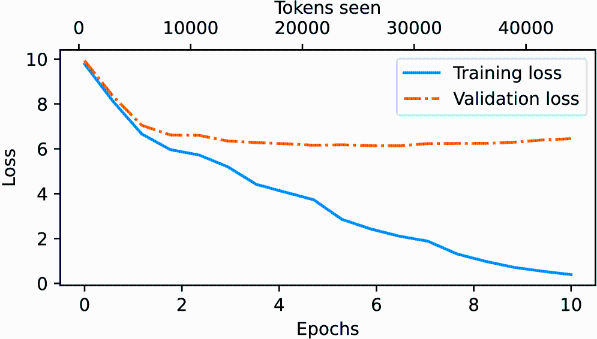

- Looking at the results above, we can see that the model starts out generating incomprehensible strings of words, whereas towards the end, it's able to produce grammatically more or less correct sentences
- However, based on the training and validation set losses, we can see that the model starts overfitting
- If we were to check a few passages it writes towards the end, we would find that they are contained in the training set verbatim -- it simply memorizes the training data
- Later, we will cover decoding strategies that can mitigate this memorization by a certain degree
- Note that the overfitting here occurs because we have a very, very small training set, and we iterate over it so many times
  - The LLM training here primarily serves educational purposes; we mainly want to see that the model can learn to produce coherent text
  - Instead of spending weeks or months on training this model on vast amounts of expensive hardware, we load pretrained weights later

![figure](https://learning.oreilly.com/api/v2/epubs/urn:orm:book:9781633437166/files/OEBPS/Images/5-13.png)

**If you are interested in augmenting this training function with more advanced techniques, such as learning rate warmup, cosine annealing, and gradient clipping, please refer to [Appendix D](../../appendix-D/01_main-chapter-code)**

**If you are interested in a larger training dataset and longer training run, see [../03_bonus_pretraining_on_gutenberg](../03_bonus_pretraining_on_gutenberg)**

## 5.3 Decoding strategies to control randomness

- Inference is relatively cheap with a relatively small LLM as the GPT model we trained above, so there's no need to use a GPU for it in case you used a GPU for training it above
- Using the `generate_text_simple` function (from the previous chapter) that we used earlier inside the simple training function, we can generate new text one word (or token) at a time
- As explained in section 5.1.2, the next generated token is the token corresponding to the largest probability score among all tokens in the vocabulary

In [ ]:
model.to("cpu")
model.eval()

tokenizer = tiktoken.get_encoding("gpt2")

token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids("Every effort moves you", tokenizer),
    max_new_tokens=25,
    context_size=GPT_CONFIG_124M["context_length"]
)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

- Even if we execute the `generate_text_simple` function above multiple times, the LLM will always generate the same outputs
- We now introduce two concepts, so-called decoding strategies, to modify the `generate_text_simple`: *temperature scaling* and *top-k* sampling
- These will allow the model to control the randomness and diversity of the generated text

### 5.3.1 Temperature scaling

Here's the Markdown format for your explanation guide with an **interactive-style structure** for clarity and interactivity:

#### *Temperature Scaling & Probabilistic Sampling in Text Generation**

##### **1. From Logits to Probabilities**

- **What Are Logits?**  
  Logits are the raw, unnormalized output scores from a model (e.g., a GPT-based model). A higher logit typically indicates that the model is more confident in that token.

- **Softmax Conversion**  
  To convert these logits into a probability distribution, we use the **softmax** function. This ensures that:  
  1. All probabilities sum to 1.  
  2. All probabilities lie between 0 and 1.

- **Greedy vs. Probabilistic**  
  - **Greedy Decoding (argmax)**: Always pick the token with the highest probability.  
  - **Probabilistic Sampling (multinomial)**: Sample the next token according to its probability. The most likely token still appears more often, but other tokens can occasionally be chosen, introducing variability.


#### **2. Introducing Temperature**

- **Definition**  
  Temperature is a hyperparameter (> 0) that **scales** the logits before the softmax function:  

- **Why Use It?**  
  - **High Temperature (> 1)**: Makes the distribution more **uniform**, increasing the chance of sampling less likely tokens.  
  - **Low Temperature (< 1)**: Sharpens the distribution, pushing probabilities closer to 1 for the most likely token.  

- **Temperature = 1**  
  - Leaves the distribution as-is (no scaling). This is the default or “standard” setting.


#### **3. Effect on Probability Distribution**

- **Distribution Examples**  
  - **Temperature = 0.1**: The highest logit dominates; the probability for the top token becomes extremely high, making sampling almost deterministic.  
  - **Temperature = 1**: Probabilities reflect the original softmax distribution from the model’s logits.  
  - **Temperature = 5**: The distribution becomes flatter; lower-probability tokens gain more share.

- Previously, we always sampled the token with the highest probability as the next token using `torch.argmax`
- To add variety, we can sample the next token using The `torch.multinomial(probs, num_samples=1)`, sampling from a probability distribution
- Here, each index's chance of being picked corresponds to its probability in the input tensor
> Multinomial Sampling: Allows tokens to be chosen based on their probability, rather than always picking the single highest-probability token.

- Here's a little recap of generating the next token, assuming a very small vocabulary for illustration purposes:

In [43]:
vocab = { 
    "closer": 0,
    "every": 1, 
    "effort": 2, 
    "forward": 3,
    "inches": 4,
    "moves": 5, 
    "pizza": 6,
    "toward": 7,
    "you": 8,
} 

inverse_vocab = {v: k for k, v in vocab.items()}

# Suppose input is "every effort moves you", and the LLM
# returns the following logits for the next token:
next_token_logits = torch.tensor(
    [4.51, 0.89, -1.90, 6.75, 1.63, -1.62, -1.89, 6.28, 1.79]
)

probas = torch.softmax(next_token_logits, dim=0)
next_token_id = torch.argmax(probas).item()

# The next generated token is then as follows:
print(inverse_vocab[next_token_id])

forward


In [44]:
torch.manual_seed(123)
next_token_id = torch.multinomial(probas, num_samples=1).item()
print(inverse_vocab[next_token_id])

toward


- Instead of determining the most likely token via `torch.argmax`, we use `torch.multinomial(probas, num_samples=1)` to determine the most likely token by sampling from the softmax distribution
- For illustration purposes, let's see what happens when we sample the next token 1,000 times using the original softmax probabilities:

In [45]:
def print_sampled_tokens(probas):
    torch.manual_seed(123) # Manual seed for reproducibility
    sample = [torch.multinomial(probas, num_samples=1).item() for i in range(1_000)]
    sampled_ids = torch.bincount(torch.tensor(sample))
    for i, freq in enumerate(sampled_ids):
        print(f"{freq} x {inverse_vocab[i]}")

print_sampled_tokens(probas)

71 x closer
2 x every
0 x effort
544 x forward
2 x inches
1 x moves
0 x pizza
376 x toward
4 x you


- We can control the distribution and selection process via a concept called temperature scaling
- "Temperature scaling" is just a fancy word for dividing the logits by a number greater than 0
- Temperatures greater than 1 will result in more uniformly distributed token probabilities after applying the softmax
- Temperatures smaller than 1 will result in more confident (sharper or more peaky) distributions after applying the softmax

In [46]:
def softmax_with_temperature(logits, temperature):
    scaled_logits = logits / temperature
    return torch.softmax(scaled_logits, dim=0)

# Temperature values
temperatures = [1, 0.1, 5]  # Original, higher confidence, and lower confidence

# Calculate scaled probabilities
scaled_probas = [softmax_with_temperature(next_token_logits, T) for T in temperatures]

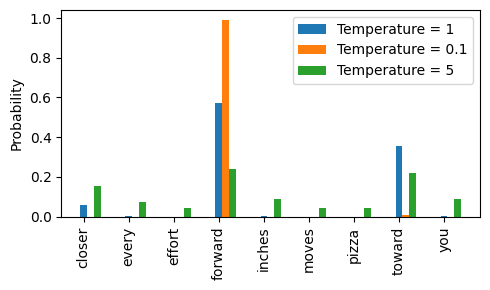

In [50]:
import matplotlib.pyplot as plt  # Add this import statement

# Plotting
x = torch.arange(len(vocab))
bar_width = 0.15

fig, ax = plt.subplots(figsize=(5, 3))
for i, T in enumerate(temperatures):
    rects = ax.bar(x + i * bar_width, scaled_probas[i], bar_width, label=f'Temperature = {T}')

ax.set_ylabel('Probability')
ax.set_xticks(x)
ax.set_xticklabels(vocab.keys(), rotation=90)
ax.legend()

plt.tight_layout()
plt.savefig("temperature-plot.pdf")
plt.show()

- We can see that the rescaling via temperature 0.1 results in a sharper distribution, approaching `torch.argmax`, such that the most likely word is almost always selected:

In [51]:
print_sampled_tokens(scaled_probas[1])

0 x closer
0 x every
0 x effort
992 x forward
0 x inches
0 x moves
0 x pizza
8 x toward


- The rescaled probabilities via temperature 5 are more uniformly distributed:

In [52]:
print_sampled_tokens(scaled_probas[2])

153 x closer
68 x every
55 x effort
223 x forward
102 x inches
50 x moves
43 x pizza
218 x toward
88 x you


- Assuming an LLM input "every effort moves you", using the approach above can sometimes result in nonsensical texts, such as "every effort moves you pizza", 3.2% of the time (32 out of 1000 times)

### 5.3.2 Top-k sampling

- To be able to use higher temperatures to increase output diversity and to reduce the probability of nonsensical sentences, we can restrict the sampled tokens to the top-k most likely tokens:



**1. The Problem with Pure Probabilistic Sampling (and Temperature)**

*   **Probabilistic Sampling:**  Instead of always picking the most likely next token (greedy decoding), we sample from the probability distribution produced by the softmax. This introduces randomness and allows for more diverse outputs.
*   **Temperature Scaling:** We can control the "randomness" of the sampling by using a temperature parameter.
    *   **High Temperature:**  Makes the probability `distribution more uniform (flatter)`.  Less likely tokens have a higher chance of being selected.  `This leads to more diverse, but potentially nonsensical, output`.
    *   **Low Temperature:**  Makes the probability distribution more peaked.  `The most likely token is even more likely to be selected.`  This leads to more predictable, but potentially repetitive, output.
*   **The Issue:** Even with temperature scaling, pure probabilistic sampling can still select very unlikely tokens, leading to grammatical errors or nonsensical text (like "every effort moves you pizza").  We want to find a balance between diversity and coherence.

**2. Top-k Sampling: The Solution**

*   **Goal:**  Improve the quality of generated text by restricting the sampling to a subset of the *most likely* tokens.
*   **How it Works (Figure 5.15):**
* ![figure](https://learning.oreilly.com/api/v2/epubs/urn:orm:book:9781633437166/files/OEBPS/Images/5-15.png)
    1.  **Select Top-k:**  Choose the `k` tokens with the highest logits (before the softmax).  `k` is a hyperparameter (e.g., k=3, k=10, k=50).
    2.  **Mask Others:**  Set the logits of all other tokens (those *not* in the top-k) to negative infinity (`-inf`).
    3.  **Softmax:** Apply the softmax function to the modified logits.  Because `exp(-inf)` is 0, the probabilities of the masked tokens become 0.  The probabilities of the top-k tokens are re-normalized to sum to 1.
    4.  **Sample:** Sample from this modified probability distribution (which now only includes the top-k tokens).



**3. Benefits of Top-k Sampling**

*   **Improved Quality:** By focusing on the most likely tokens, top-k sampling reduces the chance of generating nonsensical or grammatically incorrect text.
*   **Controlled Diversity:**  We still get diversity (unlike greedy decoding), but it's controlled by the value of `k`.
    *   **Larger `k`:**  More diversity, but potentially lower quality.
    *   **Smaller `k`:**  Less diversity, but potentially higher quality.
*   **Combined with Temperature:** Top-k sampling works well in combination with temperature scaling.  Temperature controls the "shape" of the distribution *within* the top-k tokens, while `k` controls the size of the set of considered tokens.


- In code, we can implement this as follows:

In [53]:
top_k = 3
top_logits, top_pos = torch.topk(next_token_logits, top_k)

print("Top logits:", top_logits)
print("Top positions:", top_pos)

Top logits: tensor([6.7500, 6.2800, 4.5100])
Top positions: tensor([3, 7, 0])


In [54]:
new_logits = torch.where(
    condition=next_token_logits < top_logits[-1],
    input=torch.tensor(float("-inf")), 
    other=next_token_logits
)

print(new_logits)

tensor([4.5100,   -inf,   -inf, 6.7500,   -inf,   -inf,   -inf, 6.2800,   -inf])


> NOTE:  
>
>  An alternative, slightly more efficient implementation of the previous code cell is the following:
>
> ```python
> new_logits = torch.full_like( # create tensor containing -inf values
>    next_token_logits, -torch.inf
>)   
> new_logits[top_pos] = next_token_logits[top_pos] # copy top k values into the -inf tensor
> ```
> <br>


In [55]:
topk_probas = torch.softmax(new_logits, dim=0)
print(topk_probas)

tensor([0.0615, 0.0000, 0.0000, 0.5775, 0.0000, 0.0000, 0.0000, 0.3610, 0.0000])


### 5.3.3 Modifying the text generation function

- The previous two subsections introduced temperature sampling and top-k sampling
- Let's use these two concepts to modify the `generate_simple` function we used to generate text via the LLM earlier, creating a new `generate` function:

In [56]:
def generate(model, idx, max_new_tokens, context_size, temperature=0.0, top_k=None, eos_id=None):

    # For-loop is the same as before: Get logits, and only focus on last time step
    for _ in range(max_new_tokens):
        idx_cond = idx[:, -context_size:]
        with torch.no_grad():
            logits = model(idx_cond)
        logits = logits[:, -1, :]

        # New: Filter logits with top_k sampling
        if top_k is not None:
            # Keep only top_k values
            top_logits, _ = torch.topk(logits, top_k)
            min_val = top_logits[:, -1]
            logits = torch.where(logits < min_val, torch.tensor(float("-inf")).to(logits.device), logits)

        # New: Apply temperature scaling
        if temperature > 0.0:
            logits = logits / temperature

            # Apply softmax to get probabilities
            probs = torch.softmax(logits, dim=-1)  # (batch_size, context_len)

            # Sample from the distribution
            idx_next = torch.multinomial(probs, num_samples=1)  # (batch_size, 1)

        # Otherwise same as before: get idx of the vocab entry with the highest logits value
        else:
            idx_next = torch.argmax(logits, dim=-1, keepdim=True)  # (batch_size, 1)

        if idx_next == eos_id:  # Stop generating early if end-of-sequence token is encountered and eos_id is specified
            break

        # Same as before: append sampled index to the running sequence
        idx = torch.cat((idx, idx_next), dim=1)  # (batch_size, num_tokens+1)

    return idx

In [57]:
torch.manual_seed(123)

token_ids = generate(
    model=model,
    idx=text_to_token_ids("Every effort moves you", tokenizer),
    max_new_tokens=15,
    context_size=GPT_CONFIG_124M["context_length"],
    top_k=25,
    temperature=1.4
)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves youood of vote the KEYilageeaturing, efficient.
 specialists dentist// pressuring


## 5.4 Loading and saving model weights in PyTorch

- Training LLMs is computationally expensive, so it's crucial to be able to save and load LLM weights

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch05_compressed/mental-model-3.webp" width=400px>

- The recommended way in PyTorch is to save the model weights, the so-called `state_dict` via by applying the `torch.save` function to the `.state_dict()` method:

In [ ]:
torch.save(model.state_dict(), "model.pth")

- Then we can load the model weights into a new `GPTModel` model instance as follows:

In [ ]:
model = GPTModel(GPT_CONFIG_124M)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.load_state_dict(torch.load("model.pth", map_location=device, weights_only=True))
model.eval();

- It's common to train LLMs with adaptive optimizers like Adam or AdamW instead of regular SGD
- These adaptive optimizers store additional parameters for each model weight, so it makes sense to save them as well in case we plan to continue the pretraining later:

In [ ]:
torch.save({
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    }, 
    "model_and_optimizer.pth"
)

In [ ]:
checkpoint = torch.load("model_and_optimizer.pth", weights_only=True)

model = GPTModel(GPT_CONFIG_124M)
model.load_state_dict(checkpoint["model_state_dict"])

optimizer = torch.optim.AdamW(model.parameters(), lr=0.0005, weight_decay=0.1)
optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
model.train();

## 5.5 Loading pretrained weights from OpenAI

- Previously, we only trained a small GPT-2 model using a very small short-story book for educational purposes
- Interested readers can also find a longer pretraining run on the complete Project Gutenberg book corpus in [../03_bonus_pretraining_on_gutenberg](../03_bonus_pretraining_on_gutenberg)
- Fortunately, we don't have to spend tens to hundreds of thousands of dollars to pretrain the model on a large pretraining corpus but can load the pretrained weights provided by OpenAI

<span style="color:darkred">
  <ul>
    <li>For an alternative way to load the weights from the Hugging Face Hub, see <a href="../02_alternative_weight_loading">../02_alternative_weight_loading</a></li>
    <ul>
      <li>This is useful if:</li>
      <ul>
        <li>the weights are temporarily unavailable</li>
        <li>a company VPN only permits downloads from the Hugging Face Hub but not from the OpenAI CDN, for example</li>
        <li>you are having trouble with the TensorFlow installation (the original weights are stored in TensorFlow files)</li>
      </ul>
    </ul>
    <li>The <a href="../02_alternative_weight_loading">../02_alternative_weight_loading</a> code notebooks are replacements for the remainder of this section 5.5</li>
  </ul>
</span>


- First, some boilerplate code to download the files from OpenAI and load the weights into Python
- Since OpenAI used [TensorFlow](https://www.tensorflow.org/), we will have to install and use TensorFlow for loading the weights; [tqdm](https://github.com/tqdm/tqdm) is a progress bar library
- Uncomment and run the next cell to install the required libraries

In [ ]:
# pip install tensorflow tqdm

In [ ]:
print("TensorFlow version:", version("tensorflow"))
print("tqdm version:", version("tqdm"))

In [ ]:
# Relative import from the gpt_download.py contained in this folder
from gpt_download import download_and_load_gpt2

---

**Note**

- In very rare cases, the code cell above may result in a `zsh: illegal hardware instruction python` error, which could be due to a TensorFlow installation issue on your machine
- A reader found that installing TensorFlow via `conda` solved the issue in this specific case, as mentioned [here](https://github.com/rasbt/LLMs-from-scratch/discussions/273#discussioncomment-12367888)
- You can find more instructions in this supplementary [Python setup tutorial](https://github.com/rasbt/LLMs-from-scratch/tree/main/setup/01_optional-python-setup-preferences#option-2-using-conda)

---

- We can then download the model weights for the 124 million parameter model as follows:

In [ ]:
settings, params = download_and_load_gpt2(model_size="124M", models_dir="gpt2")

In [ ]:
print("Settings:", settings)

In [ ]:
print("Parameter dictionary keys:", params.keys())

In [ ]:
print(params["wte"])
print("Token embedding weight tensor dimensions:", params["wte"].shape)

- Alternatively, "355M", "774M", and "1558M" are also supported `model_size` arguments
- The difference between these differently sized models is summarized in the figure below:

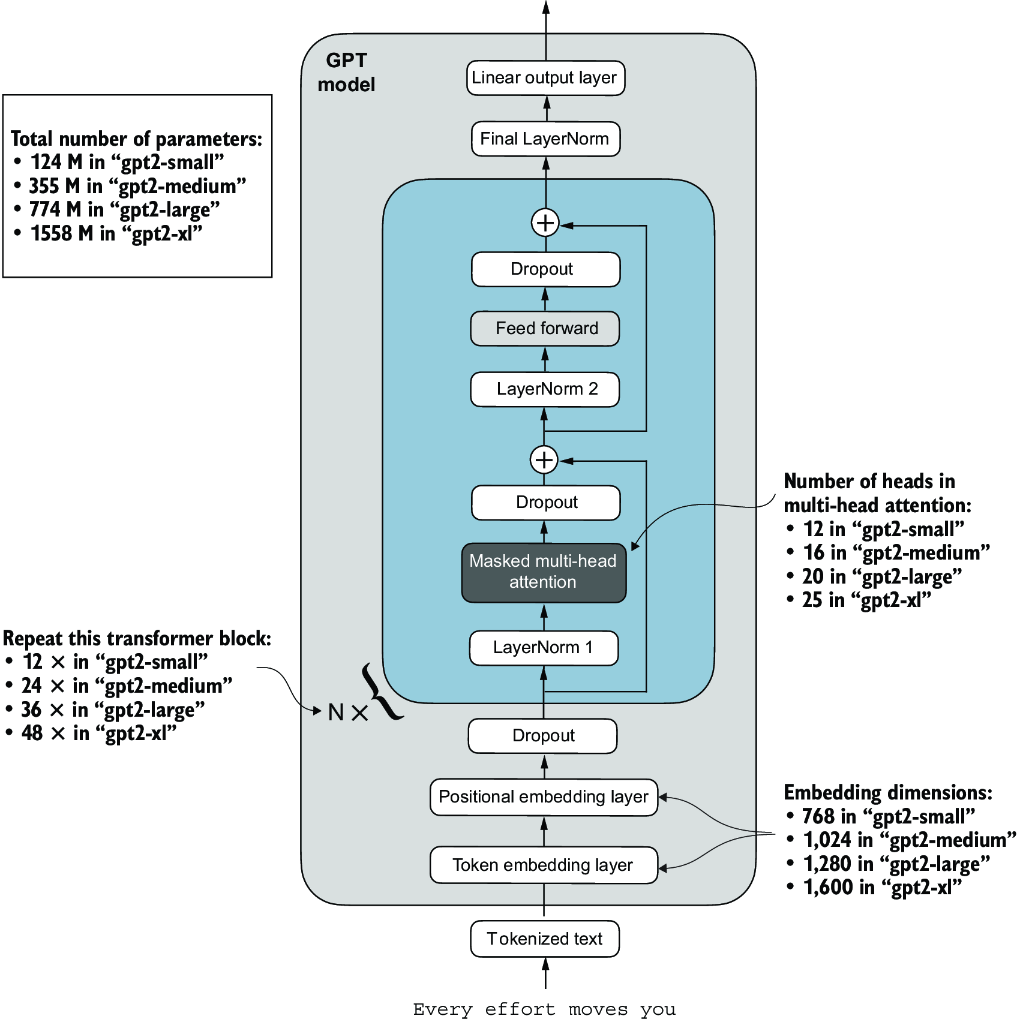

- Above, we loaded the 124M GPT-2 model weights into Python, however we still need to transfer them into our `GPTModel` instance
- First, we initialize a new GPTModel instance
- Note that the original GPT model initialized the linear layers for the query, key, and value matrices in the multi-head attention module with bias vectors, which is not required or recommended; however, to be able to load the weights correctly, we have to enable these too by setting `qkv_bias` to `True` in our implementation, too
- We are also using the `1024` token context length that was used by the original GPT-2 model(s)

> Also, OpenAI used bias vectors in the multi-head attention module’s linear layers to implement the query, key, and value matrix computations. Bias vectors are not commonly used in LLMs anymore as they don’t improve the modeling performance and are thus unnecessary.

In [ ]:
# Define model configurations in a dictionary for compactness
model_configs = {
    "gpt2-small (124M)": {"emb_dim": 768, "n_layers": 12, "n_heads": 12},
    "gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},
    "gpt2-large (774M)": {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},
    "gpt2-xl (1558M)": {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},
}

# Copy the base configuration and update with specific model settings
model_name = "gpt2-small (124M)"  # Example model name
NEW_CONFIG = GPT_CONFIG_124M.copy()
NEW_CONFIG.update(model_configs[model_name])
NEW_CONFIG.update({"context_length": 1024, "qkv_bias": True})

gpt = GPTModel(NEW_CONFIG)
gpt.eval();

- The next task is to assign the OpenAI weights to the corresponding weight tensors in our `GPTModel` instance

In [ ]:
def assign(left, right):
    if left.shape != right.shape:
        raise ValueError(f"Shape mismatch. Left: {left.shape}, Right: {right.shape}")
    return torch.nn.Parameter(torch.tensor(right))

In [ ]:
import numpy as np

def load_weights_into_gpt(gpt, params):
    gpt.pos_emb.weight = assign(gpt.pos_emb.weight, params['wpe'])
    gpt.tok_emb.weight = assign(gpt.tok_emb.weight, params['wte'])
    
    for b in range(len(params["blocks"])):
        q_w, k_w, v_w = np.split(
            (params["blocks"][b]["attn"]["c_attn"])["w"], 3, axis=-1)
        gpt.trf_blocks[b].att.W_query.weight = assign(
            gpt.trf_blocks[b].att.W_query.weight, q_w.T)
        gpt.trf_blocks[b].att.W_key.weight = assign(
            gpt.trf_blocks[b].att.W_key.weight, k_w.T)
        gpt.trf_blocks[b].att.W_value.weight = assign(
            gpt.trf_blocks[b].att.W_value.weight, v_w.T)

        q_b, k_b, v_b = np.split(
            (params["blocks"][b]["attn"]["c_attn"])["b"], 3, axis=-1)
        gpt.trf_blocks[b].att.W_query.bias = assign(
            gpt.trf_blocks[b].att.W_query.bias, q_b)
        gpt.trf_blocks[b].att.W_key.bias = assign(
            gpt.trf_blocks[b].att.W_key.bias, k_b)
        gpt.trf_blocks[b].att.W_value.bias = assign(
            gpt.trf_blocks[b].att.W_value.bias, v_b)

        gpt.trf_blocks[b].att.out_proj.weight = assign(
            gpt.trf_blocks[b].att.out_proj.weight, 
            params["blocks"][b]["attn"]["c_proj"]["w"].T)
        gpt.trf_blocks[b].att.out_proj.bias = assign(
            gpt.trf_blocks[b].att.out_proj.bias, 
            params["blocks"][b]["attn"]["c_proj"]["b"])

        gpt.trf_blocks[b].ff.layers[0].weight = assign(
            gpt.trf_blocks[b].ff.layers[0].weight, 
            params["blocks"][b]["mlp"]["c_fc"]["w"].T)
        gpt.trf_blocks[b].ff.layers[0].bias = assign(
            gpt.trf_blocks[b].ff.layers[0].bias, 
            params["blocks"][b]["mlp"]["c_fc"]["b"])
        gpt.trf_blocks[b].ff.layers[2].weight = assign(
            gpt.trf_blocks[b].ff.layers[2].weight, 
            params["blocks"][b]["mlp"]["c_proj"]["w"].T)
        gpt.trf_blocks[b].ff.layers[2].bias = assign(
            gpt.trf_blocks[b].ff.layers[2].bias, 
            params["blocks"][b]["mlp"]["c_proj"]["b"])

        gpt.trf_blocks[b].norm1.scale = assign(
            gpt.trf_blocks[b].norm1.scale, 
            params["blocks"][b]["ln_1"]["g"])
        gpt.trf_blocks[b].norm1.shift = assign(
            gpt.trf_blocks[b].norm1.shift, 
            params["blocks"][b]["ln_1"]["b"])
        gpt.trf_blocks[b].norm2.scale = assign(
            gpt.trf_blocks[b].norm2.scale, 
            params["blocks"][b]["ln_2"]["g"])
        gpt.trf_blocks[b].norm2.shift = assign(
            gpt.trf_blocks[b].norm2.shift, 
            params["blocks"][b]["ln_2"]["b"])

    gpt.final_norm.scale = assign(gpt.final_norm.scale, params["g"])
    gpt.final_norm.shift = assign(gpt.final_norm.shift, params["b"])
    gpt.out_head.weight = assign(gpt.out_head.weight, params["wte"])
    
    
load_weights_into_gpt(gpt, params)
gpt.to(device);

- If the model is loaded correctly, we can use it to generate new text using our previous `generate` function:

In [ ]:
torch.manual_seed(123)

token_ids = generate(
    model=gpt,
    idx=text_to_token_ids("Every effort moves you", tokenizer).to(device),
    max_new_tokens=25,
    context_size=NEW_CONFIG["context_length"],
    top_k=50,
    temperature=1.5
)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

- We know that we loaded the model weights correctly because the model can generate coherent text; if we made even a small mistake, the model would not be able to do that

- For an alternative way to load the weights from the Hugging Face Hub, see [../02_alternative_weight_loading](../02_alternative_weight_loading)
- If you are interested in seeing how the GPT architecture compares to the Llama architecture (a popular LLM developed by Meta AI), see the bonus content at [../07_gpt_to_llama](../07_gpt_to_llama)

## Summary and takeaways